In [2]:
import sys
sys.path.append("../../../")

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, logsumexp
from scipy.optimize import minimize
from collections import defaultdict
from tqdm import tqdm

from scipy.stats import multivariate_normal
from scipy.stats import wasserstein_distance
from scipy.stats import cramervonmises_2samp

import arviz as az
import emcee

from LRM.CMPAR1 import CMPAR1
from LRM.plotting import set_plot_style

set_plot_style()

### Model definition and sampling

In [3]:
# CMP related functions (density, sampling)

def log_p(x, lam, nu):
    """
    Unnormalised CMP model.
    """
    return x * np.log(lam) - nu * gammaln(x + 1)

def compute_cmp_pmf(lam, nu, k_max=50):
    """
    Compute the CMP PMF up to k_max using unnormalized log probabilities.
    """
    ks = np.arange(0, k_max + 1)
    log_pmf_unnorm = log_p(ks, lam, nu)
    log_Z = logsumexp(log_pmf_unnorm)
    pmf = np.exp(log_pmf_unnorm - log_Z)
    return ks, pmf

def sample_cmp(lam, nu, k_max=50):
    """
    Sample a single value from CMP via inverse transform sampling.
    """
    ks, pmf = compute_cmp_pmf(lam, nu, k_max)
    return np.random.choice(ks, p=pmf)

In [4]:
# Conditional mean specification

def log_lam_current(x_prev, log_lam_prev, theta, phi):
    """
    Compute conditional CMP parameter
    """
    return theta[0] + phi * log_lam_prev + theta[1] * np.log(1 + x_prev)


def get_all_lams(samples, theta, phi, lam0=None):
    """
    Given theta, phi, and samples, compute lam(t) for all time steps
    """
    if lam0 is None:
        lam0 = np.log(samples.mean())

    arr = [lam0]
    n = len(samples)

    for t in range(1, n):
        x_prev = samples[t-1]
        log_lam_prev = arr[t-1]
        log_lam = log_lam_current(x_prev, log_lam_prev, theta, phi)
        arr.append(log_lam)
        
    return np.exp(np.array(arr))

In [5]:
#Sampling CMP INGARCH(1,1)

def simulate_cmp_ingarch(n, theta, phi, seed=None):
    """
    Simulate from CMP-INGARCH(1,1) model

    Args:
        n (int): number of time steps
        theta (np.array): array of length 3, where theta = [theta_0, theta_1, theta_2]; theta_2 = nu (dispersion)
        phi (float, 0 < phi < 1): recursive parameter
        seed (int, optional): random seed. Defaults to None.

    Returns:
        (np.array, np.array): samples, lam(t) for all time steps
    """
    if seed is not None:
        np.random.seed(seed)

    samples = np.zeros(n, dtype=int)
    samples[0] = 1

    log_lams = [log_lam_current(samples[0], 0., theta=theta, phi=phi)]

    for t in range(1, n):
        log_lams.append(log_lam_current(x_prev=samples[t-1], log_lam_prev=log_lams[t-1], theta=theta, phi=phi))
        samples[t] = sample_cmp(np.exp(log_lams[t]), nu=theta[-1], k_max=100)

    return samples, np.exp(np.stack(log_lams))

In [6]:
# Conditional Log Likelihood Estimation

def neg_log_likelihood(samples, theta, phi, k_max=80):
    """
    Compute the conditional negative log likelihood given samples and parameters.
    """
    total = 0.0
    n = len(samples)
    log_lams = [np.log(samples.mean())]
    nu = theta[-1]

    for t in range(1, n):

        log_lams.append(log_lam_current(samples[t-1], log_lams[t-1], theta=theta, phi=phi))

        log_Z = logsumexp(log_p(x=np.arange(0, k_max), lam=np.exp(log_lams[t]), nu=nu))

        total += log_p(x=samples[t], lam=np.exp(log_lams[t]), nu=nu) - log_Z

    return -total

def optim_log_lik(samples, phi, x0, bounds):
    """
    Optimise the negative log likelihood given samples and recursive parameter (fixed).
    """
    f = lambda x : neg_log_likelihood(samples, theta=x, phi=phi)
    result = minimize(f, x0=x0, bounds=bounds)
    return result.x

In [7]:
#Computing the divergence expicitly and optimise it

def get_neighbours(x):
    """
    Get points in the matching set M(x).
    """
    return [x-1, x+1]


def compute_divergence(samples, theta, phi, empirical_pmf):
    """
    Compute the divergence given samples and parameters. 
    """
    total = 0.0
    log_lams = [np.log(samples.mean())]
    
    n = len(samples)
    assert len(theta) == 3
    count = 0
    nu = theta[-1]

    for t in range(1, n):
        x_curr = samples[t]
        x_prev = samples[t-1]
        log_lam_prev = log_lams[t-1]
        log_lams.append( log_lam_current(x_prev, log_lam_prev, theta=theta, phi=phi) )

        for x_p in get_neighbours(x_curr):
            if x_p < 0: #if x is <0, x is outside the domain
                continue

            log_ratio_p = log_p(x=x_p, lam=np.exp(log_lams[t]), nu=nu) - log_p(x=x_curr, lam=np.exp(log_lams[t]), nu=nu)
            log_ratio_q = empirical_pmf.score_samples(x_p, x_prev) - empirical_pmf.score_samples(x_curr, x_prev)

            if ~np.isneginf(log_ratio_q): #if =-\infty, most likely, x_p | x_prev is an unobserved point so we skip. 
                total += log_ratio_p**2 - 2 * log_ratio_p * log_ratio_q
                count += 1

    return (1/count) * total


def optim_div(samples, empirical_pmf, phi):
    """
    Optimise the divergence.
    """
    opt = lambda x : compute_divergence(samples, theta=x, phi=phi, empirical_pmf=empirical_pmf)
    result = minimize(opt, x0=np.zeros(3))

    return result.x

In [8]:
#Empirical distributions

class EmpiricalConditionalPMF:
    def __init__(self, observations):
        """
        Initialize with a sequence of observations.

        Parameters:
        - observations: list or array of observed values X_t
        """
        self.observations = np.array(observations)
        self.cond_pmf = self._compute_conditional_pmf()

    def _compute_conditional_pmf(self):

        cond_counts = defaultdict(lambda: defaultdict(int))
        cond_totals = defaultdict(int)

        for t in range(1, len(self.observations)):
            x_prev = self.observations[t - 1]
            x_curr = self.observations[t]
            cond_counts[x_prev][x_curr] += 1
            cond_totals[x_prev] += 1

        # Normalize to get conditional probabilities
        cond_pmf = {
            x_prev: {x: count / cond_totals[x_prev] for x, count in x_counts.items()}
            for x_prev, x_counts in cond_counts.items()
        }
        return cond_pmf

    def score_samples(self, x_curr, x_prev):

        prob = self.cond_pmf.get(x_prev, {}).get(x_curr, 0.0)
        return np.log(prob) if prob > 0 else -np.inf #return small value if unobserved
    

class SmoothedEmpiricalConditionalPMF:
    def __init__(self, x_series, k_max=10, alpha=1.0):
        """
        Initialize the smoothed empirical conditional PMF estimator.

        Parameters:
        - x_series: sequence of observed discrete values (Y_t)
        - k_max: maximum value that X_t can take (inclusive)
        - alpha: smoothing parameter (Laplace smoothing with pseudocounts)
        """
        self.k_max = k_max
        self.alpha = alpha
        self.cond_pmf = self._compute_smoothed_pmf(x_series)

    def _compute_smoothed_pmf(self, x_series):
        x_series = np.asarray(x_series)
        cond_counts = np.zeros((self.k_max + 1, self.k_max + 1), dtype=float)

        for t in range(1, len(x_series)):
            x_prev, x_curr = x_series[t - 1], x_series[t]
            if x_prev <= self.k_max and x_curr <= self.k_max:
                cond_counts[x_prev, x_curr] += 1

        cond_counts += self.alpha  # Laplace smoothing
        cond_pmf = cond_counts / cond_counts.sum(axis=1, keepdims=True)
        return cond_pmf

    def score_samples(self, x_curr, x_prev):
        """
        Return the log of the smoothed empirical conditional probability:
        log P(X_t = y_curr | X_{t-1} = y_prev)

        Parameters:
        - x_prev: value of X_{t-1}
        - x_curr: value of X_t

        Returns:
        - log probability (float)
        """
        if 0 <= x_prev <= self.k_max and 0 <= x_curr <= self.k_max:
            prob = self.cond_pmf[x_prev, x_curr]
            return np.log(prob) if prob > 0 else float("-inf")
        else:
            return float("-inf")


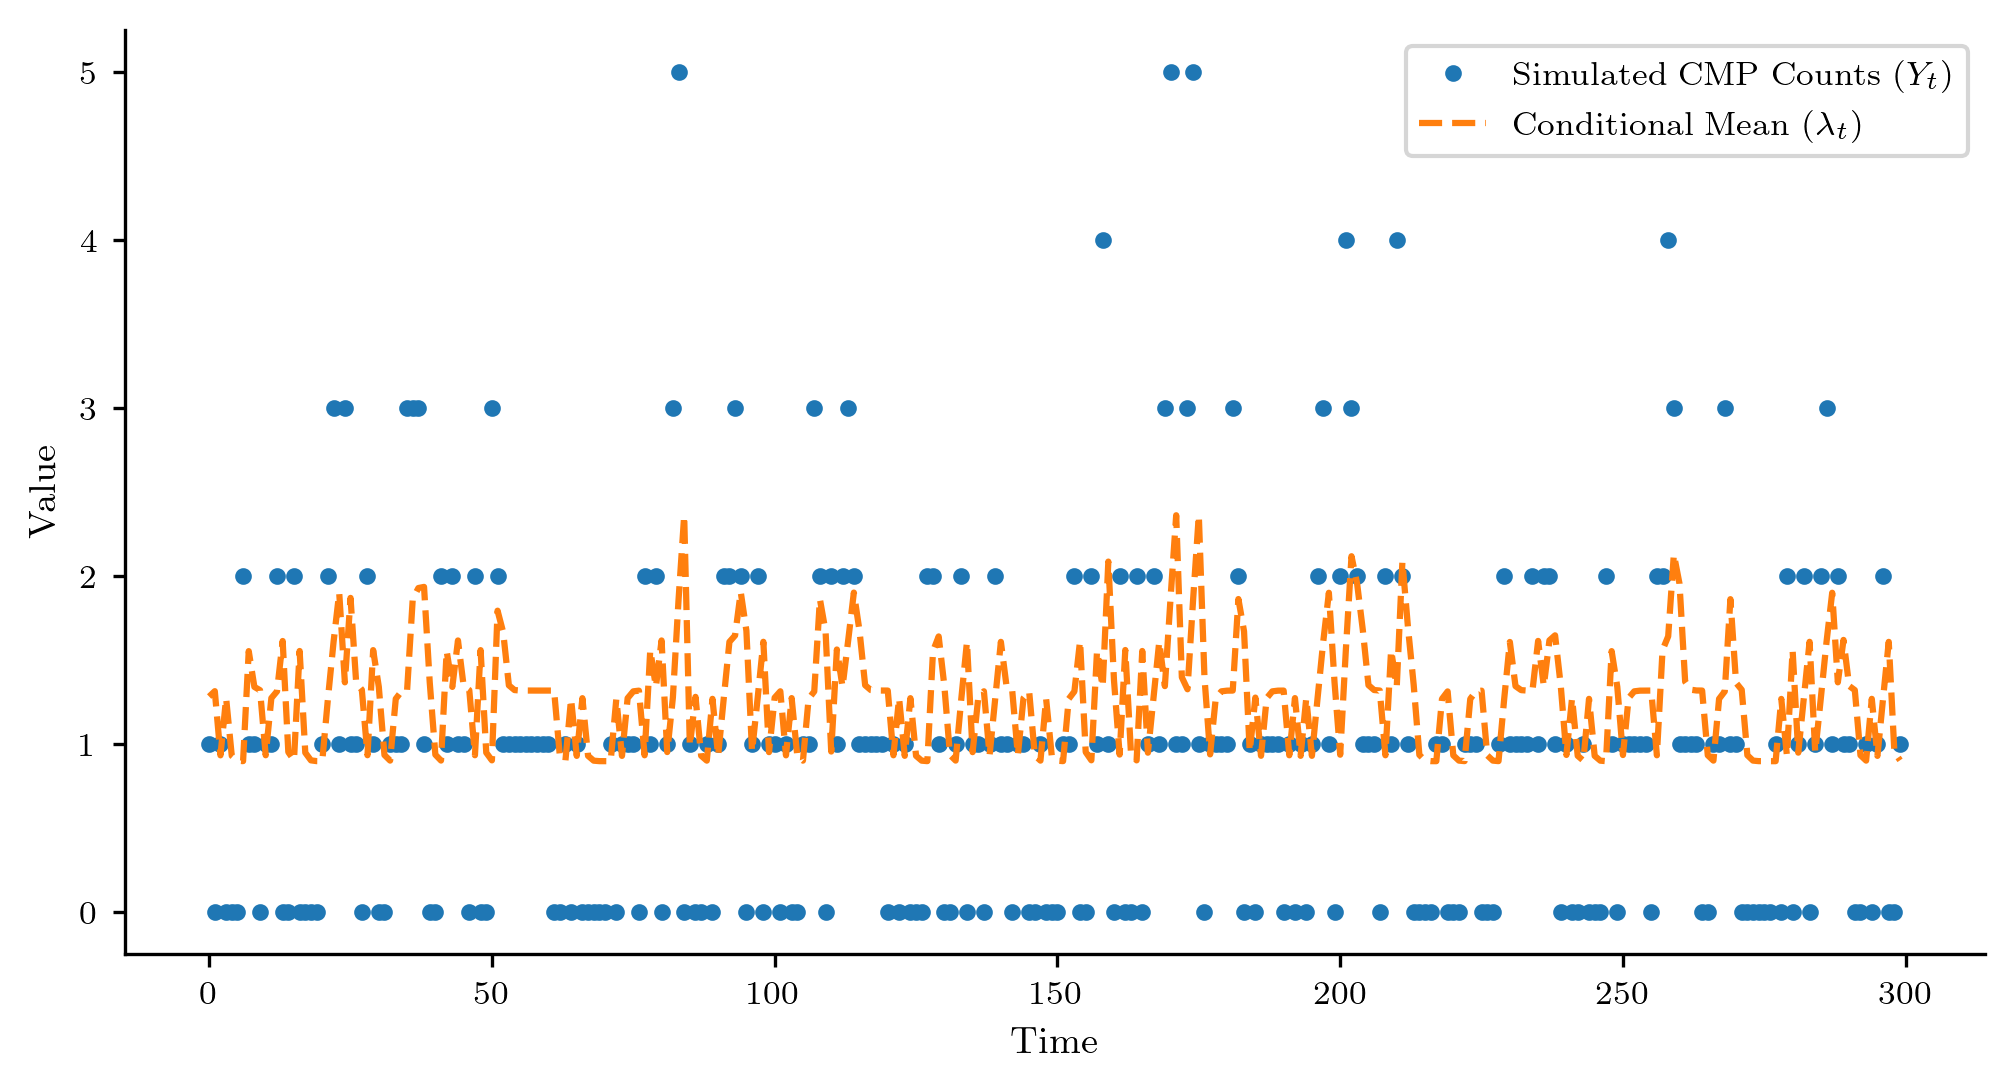

In [9]:
T = 300
true_phi = 0.1 #recursive parameter
true_theta = np.array([-0.1, 0.5, 1.5]) #conditional parameters and dispersion (last)

seed = 43

samples, true_lams = simulate_cmp_ingarch(T, theta=true_theta, phi=true_phi, seed=seed)

# Plot
plt.figure(figsize=(8,4))
plt.plot(samples, '.', label=r'Simulated CMP Counts ($Y_t$)')
plt.plot(true_lams, label=r'Conditional Mean ($\lambda_t$)', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()

# Frequentist results

In [10]:
empirical = EmpiricalConditionalPMF(samples)

result_emp = optim_div(samples, empirical_pmf=empirical, phi=true_phi)
print(true_theta)
print(result_emp)

[-0.1  0.5  1.5]
[-0.17046738  0.45857786  1.34762857]


In [11]:
result_mle = optim_log_lik(samples, phi=true_phi, x0=0.2*np.ones(3), bounds = [(-1,1), (-1,1), (-1,2)])
print(result_mle)

[-0.25127506  0.57014519  1.20149354]


In [12]:
smoothed_empirical = SmoothedEmpiricalConditionalPMF(samples, k_max=20, alpha=1.)

result_smooth_emp = optim_div(samples, empirical_pmf=smoothed_empirical, phi=true_phi)
print(true_theta)
print(result_smooth_emp)

[-0.1  0.5  1.5]
[-0.20409751  0.50595838  1.12063285]


(0.0, 50.0)

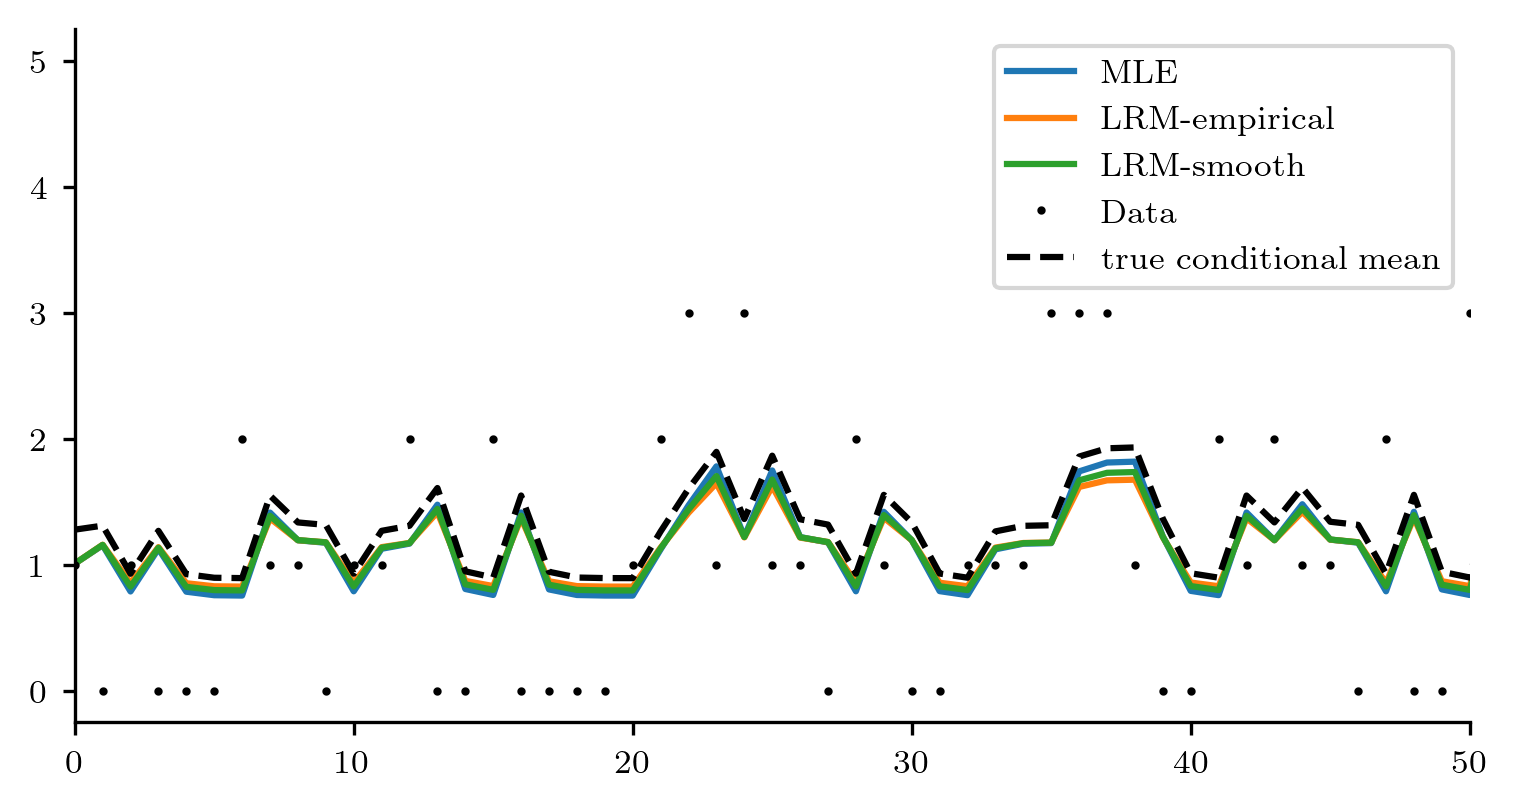

In [13]:
plt.figure(figsize=(6,3))

estim_lams = get_all_lams(samples=samples, theta=result_mle, phi=true_phi)
plt.plot(estim_lams, label='MLE')

estim_lams = get_all_lams(samples=samples, theta=result_emp, phi=true_phi)
plt.plot(estim_lams, label='LRM-empirical')


estim_lams = get_all_lams(samples=samples, theta=result_smooth_emp, phi=true_phi)
plt.plot(estim_lams, label='LRM-smooth')

plt.plot(samples, '.', label='Data', markersize=2, color='black')
plt.plot(true_lams, '--', color='black', label='true conditional mean')
plt.legend()
plt.xlim(0,50)

# Bayesian results

In [14]:
def T(x_curr, samples_curr, phi):
    t = len(samples_curr)
    t1 = x_curr * sum(phi**(n - 1) for n in range(1, t + 1))
    t2 = x_curr * sum(phi**(n - 1) * np.log(1 + samples_curr[t - n]) for n in range(1, t + 1))
    t3 = - gammaln(1 + x_curr)
    return np.array([t1, t2, t3]).reshape(-1,1)


def compute_matrices(samples, empirical, phi=0.05):
    Lambda_n = np.zeros((3,3))
    nu_n = np.zeros((3,1))

    for t in range(1, len(samples)):
        x_curr = samples[t]
        x_prev = samples[t-1]
        T_curr = T(x_curr, samples[:t], phi)

        for j in [-1, +1]:
            x_p = x_curr + j
            if x_p < 0: continue
            
            T_p = T(x_p, samples[:t], phi)
            dT = T_p - T_curr
            Lambda_n += dT @ dT.T
            nu_n += dT * (empirical.score_samples(x_p, x_prev) - empirical.score_samples(x_curr, x_prev))

    return Lambda_n, nu_n

def posterior(samples, prior_mean, prior_cov, empirical, beta, phi):
    Lambda_n, nu_n = compute_matrices(samples=samples, empirical=smoothed_empirical, phi=phi)

    assert prior_cov.shape == Lambda_n.shape and prior_mean.shape == nu_n.shape, "Prior mean or covariance has wrong shape."

    posterior_cov = np.linalg.inv( np.linalg.inv(prior_cov) + 2 * beta * Lambda_n )
    posterior_mean = posterior_cov @ (np.linalg.inv(prior_cov) @ prior_mean + 2 * beta * nu_n)

    return posterior_mean, posterior_cov


In [15]:
prior_mean = np.ones((3,1)) 
prior_cov = 0.5 * np.eye(3)
prior_dist = multivariate_normal(mean=prior_mean.flatten(), cov=prior_cov)

cmp_model = CMPAR1(samples=samples, k_max=20, alpha=1.0, phi=true_phi)
beta_hat, cov_hat, _ = cmp_model.fit_coverage(prior_mean=prior_mean, prior_cov=prior_cov, delta=0.05, B=200, beta_high=1.)
posterior_mean, posterior_cov = cmp_model.posterior(beta=beta_hat, prior_mean=prior_mean, prior_cov=prior_cov)
print(posterior_mean, posterior_cov)

[[-0.18464148]
 [ 0.50031154]
 [ 1.13541637]] [[ 0.01287249 -0.01008948  0.00653746]
 [-0.01008948  0.01990614  0.00422045]
 [ 0.00653746  0.00422045  0.02127426]]


In [16]:
mvn = multivariate_normal(mean=posterior_mean.flatten(), cov=posterior_cov)

lrm_lams = []
for i in range(5000):
    param = mvn.rvs()
    lrm_lams.append(get_all_lams(samples=samples, theta=param, phi=true_phi))

lrm_lams = np.vstack(lrm_lams)

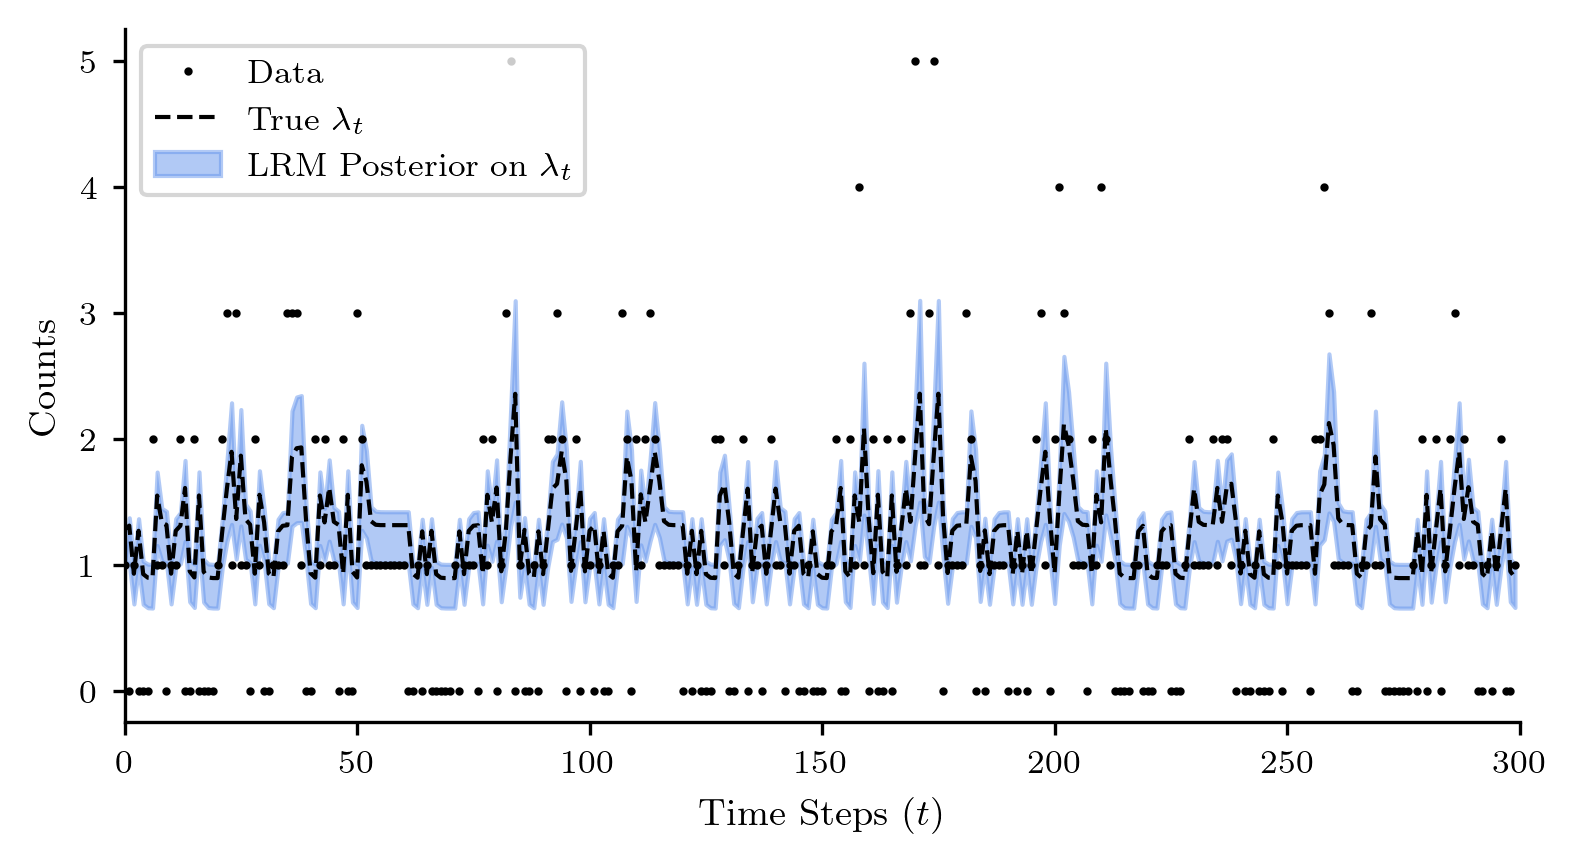

In [17]:
plt.figure(figsize=(6,3))

q05, median, q95 = np.quantile(lrm_lams, [0.05, 0.5, 0.95], axis=0)
x_range = np.arange(len(samples))

plt.plot(x_range, samples, '.', label='Data', markersize=2, color='black')
plt.plot(x_range, true_lams, '--', color='black', linewidth=1, label=r'True $\lambda_t$')

plt.fill_between(x_range, q05, q95, color='cornflowerblue', alpha=0.5, label=r"LRM Posterior on $\lambda_t$")

plt.xlim(0, 300)

plt.xlabel(r"Time Steps ($t$)")
plt.ylabel("Counts")
plt.legend()

#plt.savefig("./results/lrm-posterior-lam-INGARCH.pdf", format='pdf', bbox_inches='tight')

In [18]:
def run_mcmc(samples, prior_dist, phi):
    def log_prior(theta):
        return prior_dist.logpdf(theta)

    def log_posterior(theta):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        try:
            ll = -neg_log_likelihood(samples=samples, theta=theta, phi=phi)
        except Exception:
            return -np.inf
        return lp + ll
    
    ndim = 3
    nwalkers = 10
    nsteps = 5000
    burnin = 3000
    
    init_pos = [np.array([1.0, 0.5, 1.0]) + 1e-2 * np.random.randn(ndim) for _ in range(nwalkers)]
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
    print("Running MCMC...")
    sampler.run_mcmc(init_pos, nsteps, progress=True)
    samples = sampler.get_chain(discard=burnin, flat=True)

    idata = az.from_emcee(sampler, var_names=["theta_0", "theta_1", "theta_2"])

    return samples, idata

In [18]:
#Run only if necessary (about 8mins) 
"""
mcmc_samples, idata = run_mcmc(samples=samples, prior_dist=prior_dist, phi=true_phi)
np.savetxt("./results/mcmc_samples_AR_model_simulated_data.txt", mcmc_samples)
az.summary(idata, var_names=["theta_0", "theta_1", "theta_2"])
"""

'\nmcmc_samples, idata = run_mcmc(samples=samples, prior_dist=prior_dist, phi=true_phi)\nnp.savetxt("./results/mcmc_samples_AR_model_simulated_data.txt", mcmc_samples)\naz.summary(idata, var_names=["theta_0", "theta_1", "theta_2"])\n'

In [19]:
mcmc_samples = np.loadtxt("./results/mcmc_samples_AR_model_simulated_data.txt")

In [20]:
mcmc_lams = []
for mcmc_sample in mcmc_samples:
    mcmc_lams.append(get_all_lams(samples=samples, theta=mcmc_sample, phi=true_phi))

mcmc_lams = np.stack(mcmc_lams)[:len(lrm_lams)]

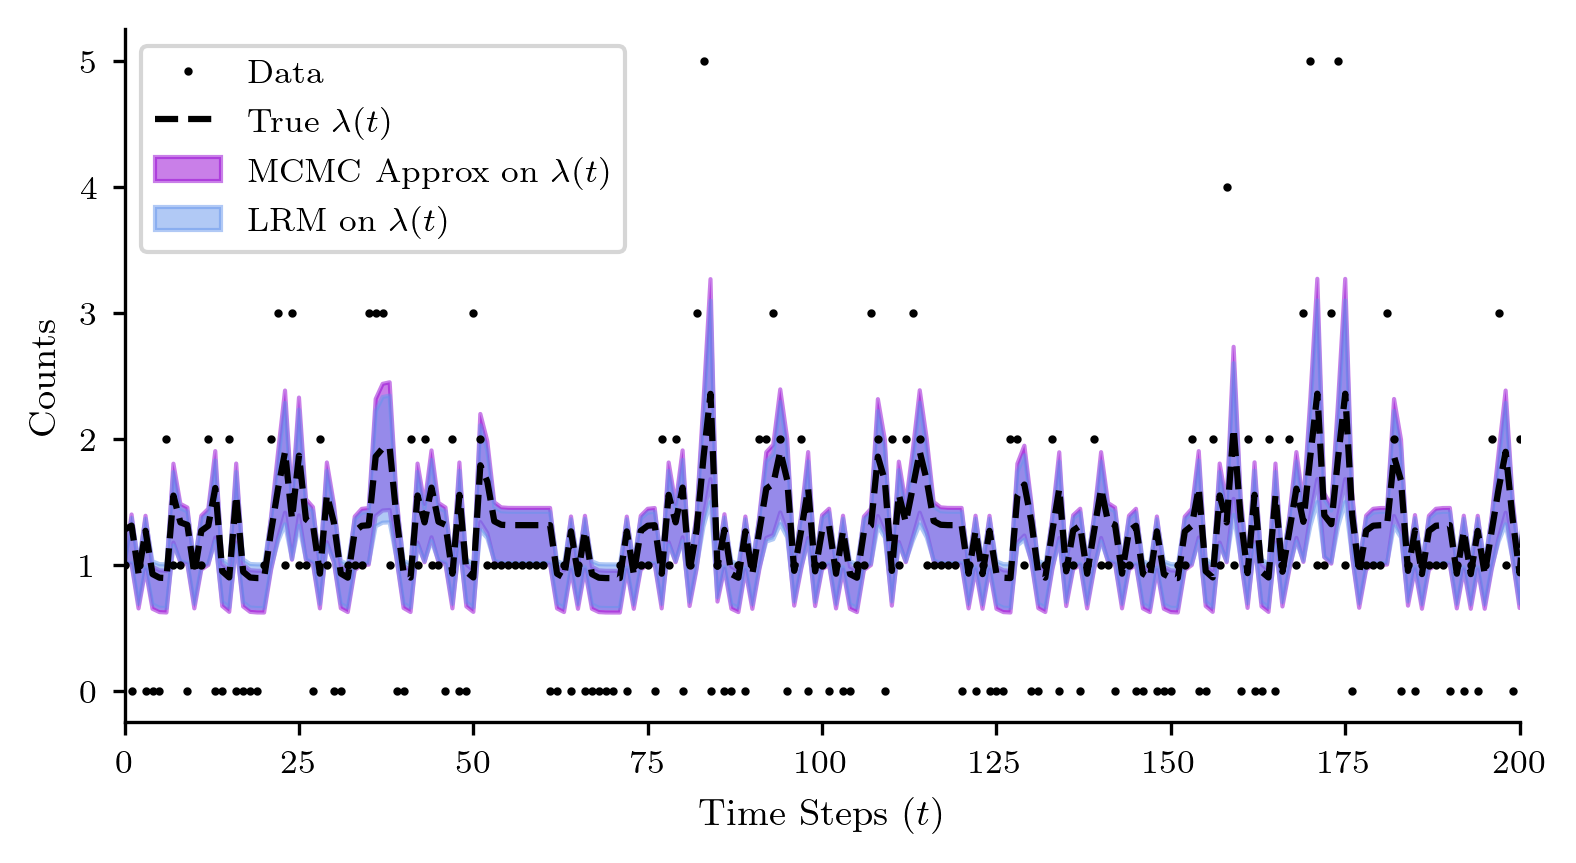

In [ ]:
plt.figure(figsize=(6,3))

q05, median, q95 = np.quantile(mcmc_lams, [0.05, 0.5, 0.95], axis=0)
x_range = np.arange(len(samples))

plt.plot(x_range, samples, '.', label='Data', markersize=2, color='black')
plt.plot(x_range, true_lams, '--', color='black', label=r'True $\lambda(t)$')

plt.fill_between(x_range, q05, q95, color='darkviolet', alpha=0.5, label=r"MCMC Approx on $\lambda(t)$")

q05, median, q95 = np.quantile(lrm_lams, [0.05, 0.5, 0.95], axis=0)
plt.fill_between(x_range, q05, q95, color='cornflowerblue', alpha=0.5, label=r"LRM on $\lambda(t)$")

plt.xlim(0, 200)

plt.xlabel(r"Time Steps ($t$)")
plt.ylabel("Counts")
plt.legend()
#plt.savefig("./results/lrm-vs-mcmc-posterior-lam-INGARCH-sim.pdf", format='pdf', bbox_inches='tight')

Mean Wasserstein distance: 0.0338


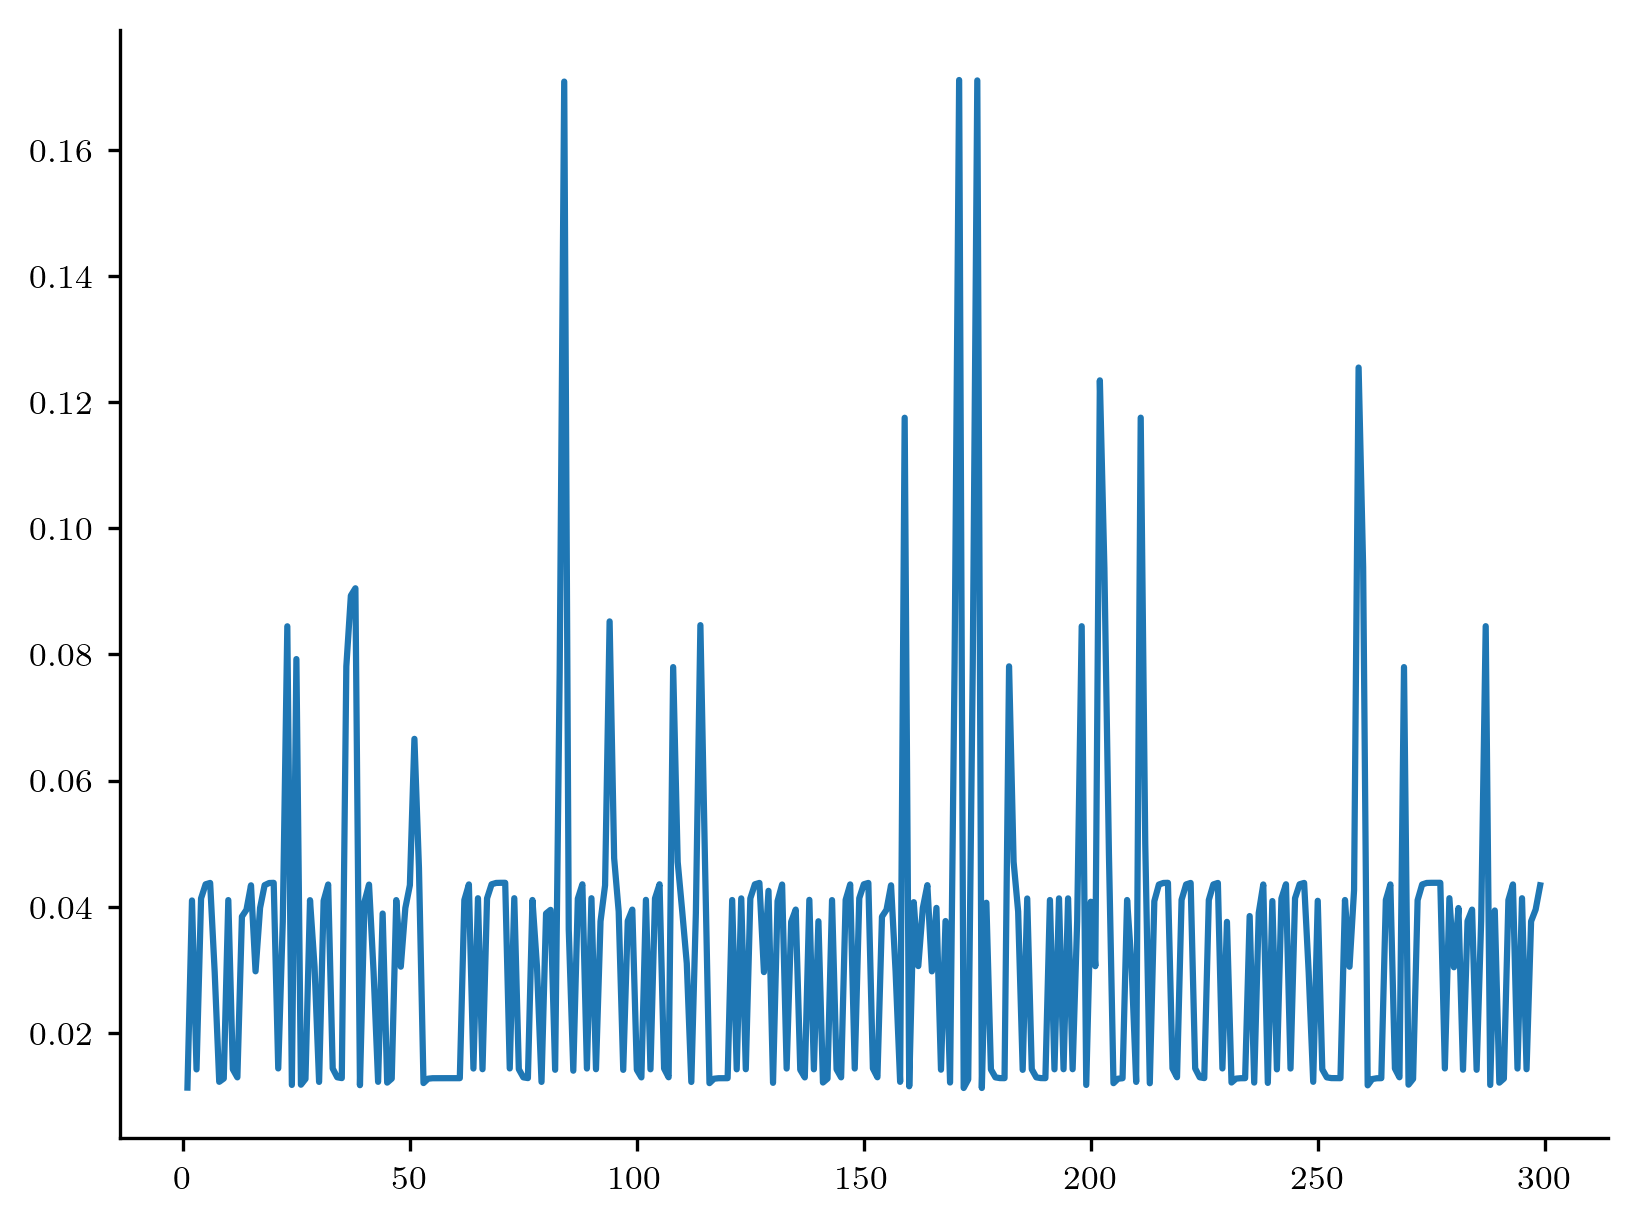

In [22]:
w_distances = [wasserstein_distance(mcmc_lams[:, t], lrm_lams[:, t]) for t in range(mcmc_lams.shape[1])]
plt.plot(range(1, mcmc_lams.shape[1]), w_distances[1:])
avg_w = np.mean(w_distances)
print(f"Mean Wasserstein distance: {avg_w:.4f}")